## Import library

In [1]:
import numpy as np
import pandas as pd
import evaluate
import torch
import matplotlib.pyplot as plt
 

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Is Mac GPU (MPS) available?", torch.backends.mps.is_available())

Is Mac GPU (MPS) available? True


## Load dataset

In [3]:
train_df = pd.read_pickle("train_set.pkl")
test_df = pd.read_pickle("test_set.pkl")

train_df = train_df.rename(columns={"label": "num_label"})
test_df = test_df.rename(columns={"label": "num_label"})

print(train_df.shape)
print(test_df.shape)
print(train_df.columns)

(175, 7)
(44, 7)
Index(['signal_data', 'language', 'speaker', 'num_label', 'gender', 'c',
       'length'],
      dtype='str')


In [4]:
# Convert string into categorical data
train_df['language'] = train_df['language'].astype('category')
test_df['language']  = test_df['language'].astype('category')
label_names = train_df['language'].cat.categories.tolist()

# Create mapper
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for i, label in enumerate(label_names)}

train_df['label'] = train_df['language'].cat.codes
test_df['label'] = test_df['language'].cat.codes

In [5]:
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})

In [6]:
train_df.head()

,signal_data,language,speaker,num_label,gender,c,length,label
176,"[0.000152587890625, 0.000823974609375, 0.00082...",SA,A,4,F,c,9501,3
165,"[-3.0517578125e-05, 0.0, 0.0, 0.0, 3.051757812...",FR,F,2,F,c,6201,0
126,"[9.1552734375e-05, 0.000152587890625, 0.000244...",FR,B,3,F,c,10001,0
103,"[0.0, 0.0, 0.0, -0.0078125, 0.0, -0.0078125, -...",SI,C,9,M,c,9001,4
70,"[-0.010894775390625, -0.018310546875, -0.00708...",IT,E,5,F,c,15000,1


## wav2vec2-xls-r-300m model loading
https://huggingface.co/facebook/wav2vec2-xls-r-300m

In [7]:
model_id = "facebook/wav2vec2-xls-r-300m"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

In [8]:
def preprocess_function(examples):
    # Extract the raw float arrays from 'signal_data'
    audio_arrays = examples["signal_data"]
    
    # Process audio arrays. XLS-R expects 16000Hz arrays
    inputs = feature_extractor(
        audio_arrays,
        sampling_rate=16000,
        max_length=16000, # Adjust based on your max sample length (e.g., 16000 = 1 sec)
        truncation=True,
        padding="max_length" # Padding ensures uniform tensor shapes for stable training
    )
    
    # Pass the numerical labels through
    inputs["label"] = examples["label"]
    return inputs

In [9]:
encoded_datasets = raw_datasets.map(
    preprocess_function, 
    batched=True, 
    remove_columns=raw_datasets["train"].column_names
)

Map: 100%|██████████| 44/44 [00:00<00:00, 572.46 examples/s]


In [10]:
# Model initialization
model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=len(label_names),
    label2id=label2id,
    id2label=id2label
)

Loading weights: 100%|██████████| 422/422 [00:00<00:00, 75861.32it/s]
[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
model.freeze_feature_encoder()
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    acc = accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)
    f1 = f1_metric.compute(predictions=predictions, references=eval_pred.label_ids, average="weighted")
    
    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }

In [ ]:
# UPDATED: Removed use_mps_device=True
training_args = TrainingArguments(
    output_dir="./wav2vec2-low-resource-lang-2",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,              # Slightly increased to help it learn a bit faster
    per_device_train_batch_size=4,   
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,   
    gradient_checkpointing=True,     
    num_train_epochs=35,             # Increased from 15 to 35 because it was still learning!
    warmup_steps=20,                 # Increased to match the longer training schedule
    logging_steps=5,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_datasets["train"],
    eval_dataset=encoded_datasets["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)], # Stops if accuracy doesn't improve for 5 epochs

)

# --- 6. Train ---
trainer.train()

/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,12.862970,1.608505,0.227273,0.084175
2,11.550847,1.600656,0.227273,0.084175
3,11.461369,1.588348,0.386364,0.291322
4,11.432294,1.574839,0.431818,0.288731
5,11.183788,1.562492,0.477273,0.326263
6,12.349226,1.542591,0.454545,0.304311
7,10.895191,1.506041,0.477273,0.319559
8,10.971693,1.479929,0.431818,0.294942
9,10.706567,1.364170,0.500000,0.333641
10,9.945287,1.282254,0.500000,0.333333


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.10it/s]
/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]
/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]
/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.34it/s]
/opt/miniconda3/envs/kcl/lib/

In [ ]:
trainer.save_model("./final-wav2vec2-language-classifier-2")
print("Training complete! Best model successfully saved to ./final-wav2vec2-language-classifier")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.16it/s]

Training complete! Best model successfully saved to ./final-wav2vec2-language-classifier


## Model evaluation

In [ ]:
# --- 8. Load and Evaluate the Saved Model ---
print("\n--- Evaluating Final Saved Model ---")

# Load the best model from the saved directory
loaded_model = AutoModelForAudioClassification.from_pretrained("./final-wav2vec2-language-classifier-2")

# Initialize a new Trainer for evaluation using the loaded model
eval_trainer = Trainer(
    model=loaded_model,
    args=training_args,
    train_dataset=encoded_datasets["train"], # ADDED: Provide the train set
    eval_dataset=encoded_datasets["test"],   # ADDED: Provide the test set to fix ValueError
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

# 8a. Evaluate on the Test Set
print("Evaluating on Test Set...")
test_results = eval_trainer.evaluate(eval_dataset=encoded_datasets["test"])
print(f"TEST RESULTS  -> Loss: {test_results['eval_loss']:.4f} | Accuracy: {test_results['eval_accuracy']:.4f} | F1: {test_results['eval_f1']:.4f}")

# 8b. Evaluate on the Training Set
print("Evaluating on Training Set...")
# We use metric_key_prefix="train" so the outputs are labelled as train_loss, train_accuracy, etc.
train_results = eval_trainer.evaluate(eval_dataset=encoded_datasets["train"], metric_key_prefix="train")
print(f"TRAIN RESULTS -> Loss: {train_results['train_loss']:.4f} | Accuracy: {train_results['train_accuracy']:.4f} | F1: {train_results['train_f1']:.4f}")



--- Evaluating Final Saved Model ---


Loading weights: 100%|██████████| 426/426 [00:00<00:00, 13756.58it/s]


Evaluating on Test Set...


/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.523042,0,0.840909,0.789343


TEST RESULTS  -> Loss: 0.5230 | Accuracy: 0.8409 | F1: 0.7893
Evaluating on Training Set...


/opt/miniconda3/envs/kcl/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.296303,0,0.902857,0.890328


TRAIN RESULTS -> Loss: 0.2963 | Accuracy: 0.9029 | F1: 0.8903


## Plot training history


--- Plotting Training History ---
Saved training plot to './training_history.png'


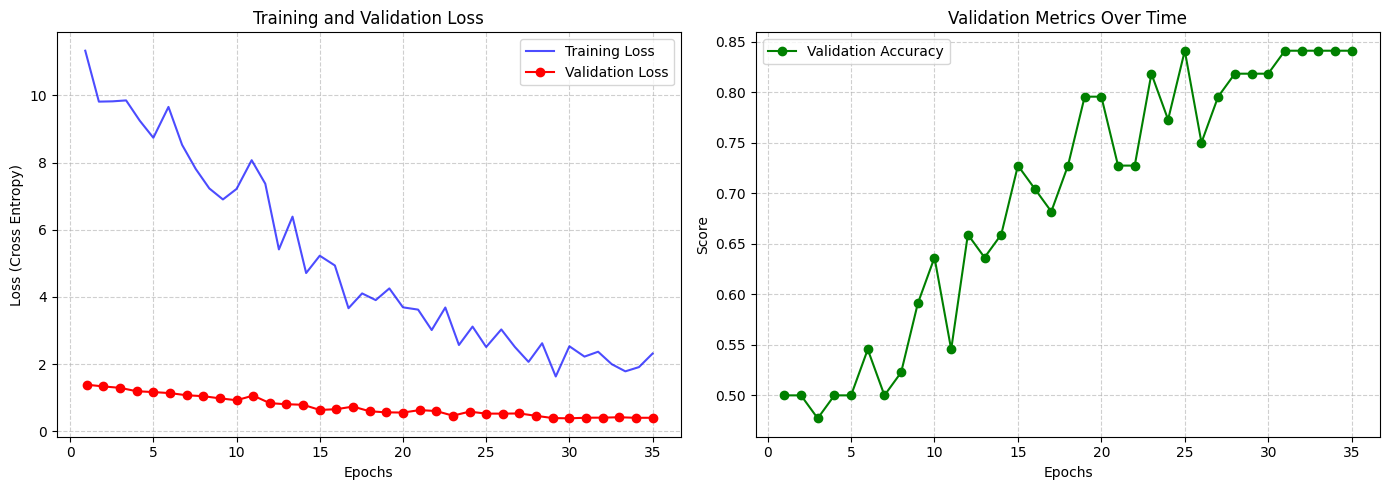

In [ ]:
# --- 9. Plot Training History ---
print("\n--- Plotting Training History ---")
log_history = trainer.state.log_history

# Extract metrics (Trainer logs training loss and eval metrics at different steps/epochs)
train_loss = [log['loss'] for log in log_history if 'loss' in log]
train_epochs = [log['epoch'] for log in log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_acc = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]
eval_f1 = [log['eval_f1'] for log in log_history if 'eval_f1' in log]
eval_epochs = [log['epoch'] for log in log_history if 'eval_loss' in log]

# Create subplots
plt.figure(figsize=(14, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(train_epochs, train_loss, label='Training Loss', color='blue', alpha=0.7)
plt.plot(eval_epochs, eval_loss, label='Validation Loss', color='red', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Cross Entropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Accuracy & F1
plt.subplot(1, 2, 2)
plt.plot(eval_epochs, eval_acc, label='Validation Accuracy', color='green', marker='o')

# Safely check if F1 scores were tracked during this training run before plotting
if eval_f1:
    plt.plot(eval_epochs, eval_f1, label='Validation F1 Score', color='purple', marker='x', linestyle='--')

plt.title('Validation Metrics Over Time')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the plot to an image file and display it
plt.savefig("./training_history.pdf", dpi=300)
print("Saved training plot to './training_history.pdf'")
plt.show()